In [23]:
# Carga del conjunto de datos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('https://breathecode.herokuapp.com/asset/internal-link?id=733&path=demographic_health_data.csv')

print(f'Dimensiones: {df.shape}')
pd.set_option('display.max_columns', None)
df.head()

Dimensiones: (3140, 108)


,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,40-49,40-49 y/o % of total pop,50-59,50-59 y/o % of total pop,60-69,60-69 y/o % of total pop,70-79,70-79 y/o % of total pop,80+,80+ y/o % of total pop,White-alone pop,% White-alone,Black-alone pop,% Black-alone,Native American/American Indian-alone pop,% NA/AI-alone,Asian-alone pop,% Asian-alone,Hawaiian/Pacific Islander-alone pop,% Hawaiian/PI-alone,Two or more races pop,% Two or more races,POP_ESTIMATE_2018,N_POP_CHG_2018,GQ_ESTIMATES_2018,R_birth_2018,R_death_2018,R_NATURAL_INC_2018,R_INTERNATIONAL_MIG_2018,R_DOMESTIC_MIG_2018,R_NET_MIG_2018,Less than a high school diploma 2014-18,High school diploma only 2014-18,Some college or associate's degree 2014-18,Bachelor's degree or higher 2014-18,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a high school diploma only 2014-18,Percent of adults completing some college or associate's degree 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,POVALL_2018,PCTPOVALL_2018,PCTPOV017_2018,PCTPOV517_2018,MEDHHINC_2018,CI90LBINC_2018,CI90UBINC_2018,Civilian_labor_force_2018,Employed_2018,Unemployed_2018,Unemployment_rate_2018,Median_Household_Income_2018,Med_HH_Income_Percent_of_State_Total_2018,Active Physicians per 100000 Population 2018 (AAMC),Total Active Patient Care Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC),Active General Surgeons per 100000 Population 2018 (AAMC),Active Patient Care General Surgeons per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),Internal Medicine Primary Care (2019),Family Medicine/General Practice Primary Care (2019),Total Specialist Physicians (2019),ICU Beds_x,Total Population,Population Aged 60+,Percent of Population Aged 60+,COUNTY_NAME,STATE_NAME,STATE_FIPS,CNTY_FIPS,county_pop2018_18 and older,anycondition_prevalence,anycondition_Lower 95% CI,anycondition_Upper 95% CI,anycondition_number,Obesity_prevalence,Obesity_Lower 95% CI,Obesity_Upper 95% CI,Obesity_number,Heart disease_prevalence,Heart disease_Lower 95% CI,Heart disease_Upper 95% CI,Heart disease_number,COPD_prevalence,COPD_Lower 95% CI,COPD_Upper 95% CI,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,7582,13.636445,7738,13.917016,5826,10.478229,4050,7.284042,2014,3.622237,42660,76.725239,10915,19.630942,267,0.480207,681,1.224798,62,0.111509,1016,1.827305,55601,158,455,11.8,9.6,2.2,0.0,0.7,0.6,4204,12119,10552,10291,11.3,32.6,28.4,27.7,7587,13.8,19.3,19.5,59338,53628,65048,25957,25015,942,3.6,59338,119.0,217.1,196.7,77.2,71.2,7.6,6.9,28.859137,6.085786,1.148905,25.992561,21.249061,72.142154,6,55036,10523,19.1,Autauga,Alabama,1,1,42438,47.6,45.4,49.4,20181,35.8,34.2,37.3,15193,7.9,7.2,8.7,3345,8.6,7.3,9.9,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,27338,12.539102,29986,13.753658,29932,13.728890,20936,9.602701,9368,4.296814,190301,87.285228,19492,8.940382,1684,0.772399,2508,1.150343,146,0.066966,3891,1.784682,218022,5403,2190,10.5,10.3,0.1,0.5,24.3,24.8,14310,40579,46025,46075,9.7,27.6,31.3,31.3,21069,9.8,13.9,13.1,57588,54437,60739,93849,90456,3393,3.6,57588,115.5,217.1,196.7,77.2,71.2,7.6,6.9,113.162114,23.863512,4.505074,101.921730,83.321572,282.882982,51,203360,53519,26.3,Baldwin,Alabama,1,3,170912,40.2,38.2,42.3,68790,29.7,28.4,31.0,50761,7.8,7.0,8.7,13414,8.6,7.2,10.1,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,3074,12.354809,3278,13.174712,3076,12.3

In [24]:
# Análisis Exploratorio de datos (EDA)

print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print()
print('Tipos de datos:')
print(df.dtypes.value_counts())
print()
nulls = df.isnull().sum()
print('Valores nulos:')
print(nulls[nulls > 0] if nulls.any() else 'Sin valores nulos')

Filas: 3140 | Columnas: 108

Tipos de datos:
float64    61
int64      45
str         2
Name: count, dtype: int64

Valores nulos:
Sin valores nulos


In [25]:
# Estadísticas descriptivas de variables clave
key_cols = [
    'Heart disease_number', 'Obesity_number', 'diabetes_number',
    'COPD_number', 'PCTPOVALL_2018', 'Unemployment_rate_2018',
    'Median_Household_Income_2018', 'Active Physicians per 100000 Population 2018 (AAMC)'
]
df[key_cols].describe().round(2)

,Heart disease_number,Obesity_number,diabetes_number,COPD_number,PCTPOVALL_2018,Unemployment_rate_2018,Median_Household_Income_2018,Active Physicians per 100000 Population 2018 (AAMC)
count,3140.00,3140.00,3140.00,3140.00,3140.00,3140.00,3140.00,3140.00
mean,5597.59,25276.13,9326.58,5827.24,15.16,4.13,52767.08,254.92
std,15615.29,74466.84,29754.60,15720.55,6.13,1.50,13907.99,42.29
min,7.00,25.00,11.00,7.00,0.00,0.00,0.00,191.30
25%,798.50,3075.00,1187.75,815.00,10.80,3.10,43677.00,227.60
50%,1814.50,7182.50,2743.00,1963.50,14.10,3.90,50564.50,247.10
75%,4376.00,18542.50,6679.25,4727.00,18.30,4.80,58822.25,278.80
max,434790.00,2097906.00,952335.00,434075.00,54.00,19.90,140382.00,847.00


In [26]:
# Selección de variables
# Variable Objetivo: Heart disease_number - número absoluto de personas con enfermedad cardíaca por condado.
selected_cols = [
    # Demografía — conteos absolutos por franja de edad
    '0-9', '20-29', '30-39', '40-49', '50-59', '60-69', '70-79', '80+',
    # Demografía — raza (conteos)
    'White-alone pop', 'Black-alone pop', 'Asian-alone pop',
    # Socioeconómico
    'PCTPOVALL_2018',
    'Unemployment_rate_2018',
    'Median_Household_Income_2018',
    'Percent of adults with less than a high school diploma 2014-18',
    "Percent of adults with a bachelor's degree or higher 2014-18",
    'R_birth_2018',
    'R_death_2018',
    'Urban_rural_code',
    # Recursos sanitarios
    'Active Physicians per 100000 Population 2018 (AAMC)',
    'Active Primary Care Physicians per 100000 Population 2018 (AAMC)',
    'Total nurse practitioners (2019)',
    'Total physician assistants (2019)',
    'Total Hospitals (2019)',
    'ICU Beds_x',
    # Otras condiciones (en número absoluto, consistente con la variable objetivo)
    'Obesity_number',
    'diabetes_number',
    'COPD_number',
    'CKD_number',
    # Variable objetivo
    'Heart disease_number'
]

df_sel = df[selected_cols].copy()
print(f'Variables seleccionadas: {df_sel.shape[1]} (de {df.shape[1]})')
df_sel.head()

Variables seleccionadas: 30 (de 108)


,0-9,20-29,30-39,40-49,50-59,60-69,70-79,80+,White-alone pop,Black-alone pop,Asian-alone pop,PCTPOVALL_2018,Unemployment_rate_2018,Median_Household_Income_2018,Percent of adults with less than a high school diploma 2014-18,Percent of adults with a bachelor's degree or higher 2014-18,R_birth_2018,R_death_2018,Urban_rural_code,Active Physicians per 100000 Population 2018 (AAMC),Active Primary Care Physicians per 100000 Population 2018 (AAMC),Total nurse practitioners (2019),Total physician assistants (2019),Total Hospitals (2019),ICU Beds_x,Obesity_number,diabetes_number,COPD_number,CKD_number,Heart disease_number
0,6787,6878,7089,7582,7738,5826,4050,2014,42660,10915,681,13.8,3.6,59338,11.3,27.7,11.8,9.6,3,217.1,77.2,28.859137,6.085786,1.148905,6,15193,5462,3644,1326,3345
1,24757,23579,25213,27338,29986,29932,20936,9368,190301,19492,2508,9.8,3.6,57588,9.7,31.3,10.5,10.3,4,217.1,77.2,113.162114,23.863512,4.505074,51,50761,20520,14692,5479,13414
2,2732,3268,3201,3074,3278,3076,2244,1048,12209,12042,113,30.9,5.2,34382,27.0,12.2,10.4,12.9,6,217.1,77.2,12.914231,2.723340,0.514126,5,8013,3870,2373,887,2159
3,2456,3029,3113,3038,3115,2545,1723,785,17211,4770,53,21.8,4.0,46064,16.8,11.5,11.1,11.4,2,217.1,77.2,11.626493,2.451783,0.462860,0,6894,2511,1789,595,1533
4,7095,6742,6884,7474,7844,6965,4931,2335,55456,950,185,13.2,3.5,50412,19.8,12.6,11.8,11.4,2,217.1,77.2,30.021267,6.330854,1.195171,6,15112,6017,4661,1507,4101


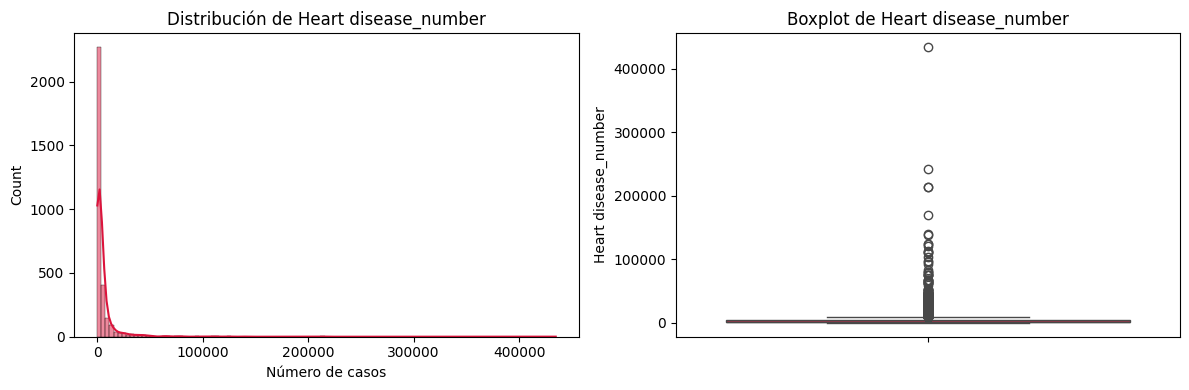

Media:   5,598 casos
Mediana: 1,814 casos
Std:     15,615 casos
Min:     7 | Max: 434,790


In [27]:
# Análisis variable objetivo

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df_sel['Heart disease_number'], kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Distribución de Heart disease_number')
axes[0].set_xlabel('Número de casos')

sns.boxplot(y=df_sel['Heart disease_number'], ax=axes[1], color='crimson')
axes[1].set_title('Boxplot de Heart disease_number')

plt.tight_layout()
plt.show()

print(f"Media:   {df_sel['Heart disease_number'].mean():,.0f} casos")
print(f"Mediana: {df_sel['Heart disease_number'].median():,.0f} casos")
print(f"Std:     {df_sel['Heart disease_number'].std():,.0f} casos")
print(f"Min:     {df_sel['Heart disease_number'].min():,.0f} | Max: {df_sel['Heart disease_number'].max():,.0f}")

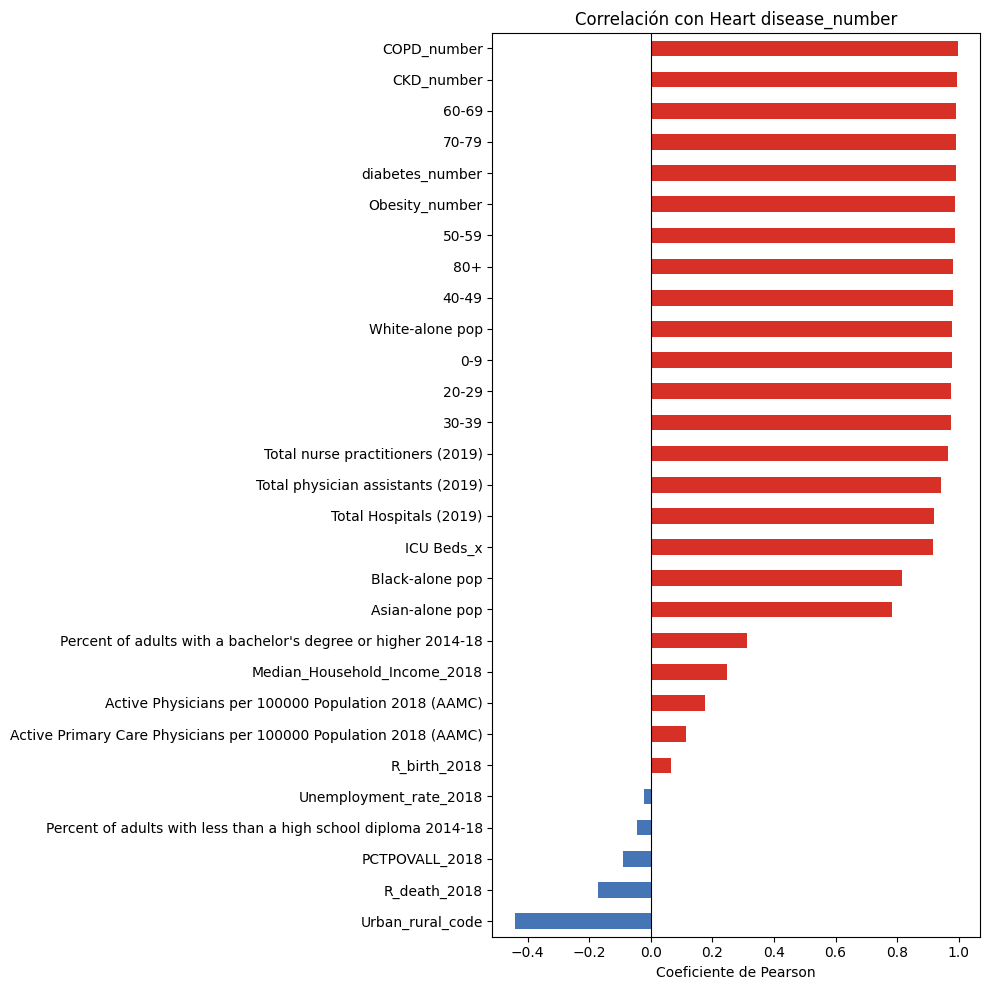

In [28]:
# Correlaciones con la variable objetivo

corr_target = df_sel.corr()['Heart disease_number'].drop('Heart disease_number').sort_values()

fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#d73027' if v > 0 else '#4575b4' for v in corr_target.values]
corr_target.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación con Heart disease_number')
ax.set_xlabel('Coeficiente de Pearson')
plt.tight_layout()
plt.show()

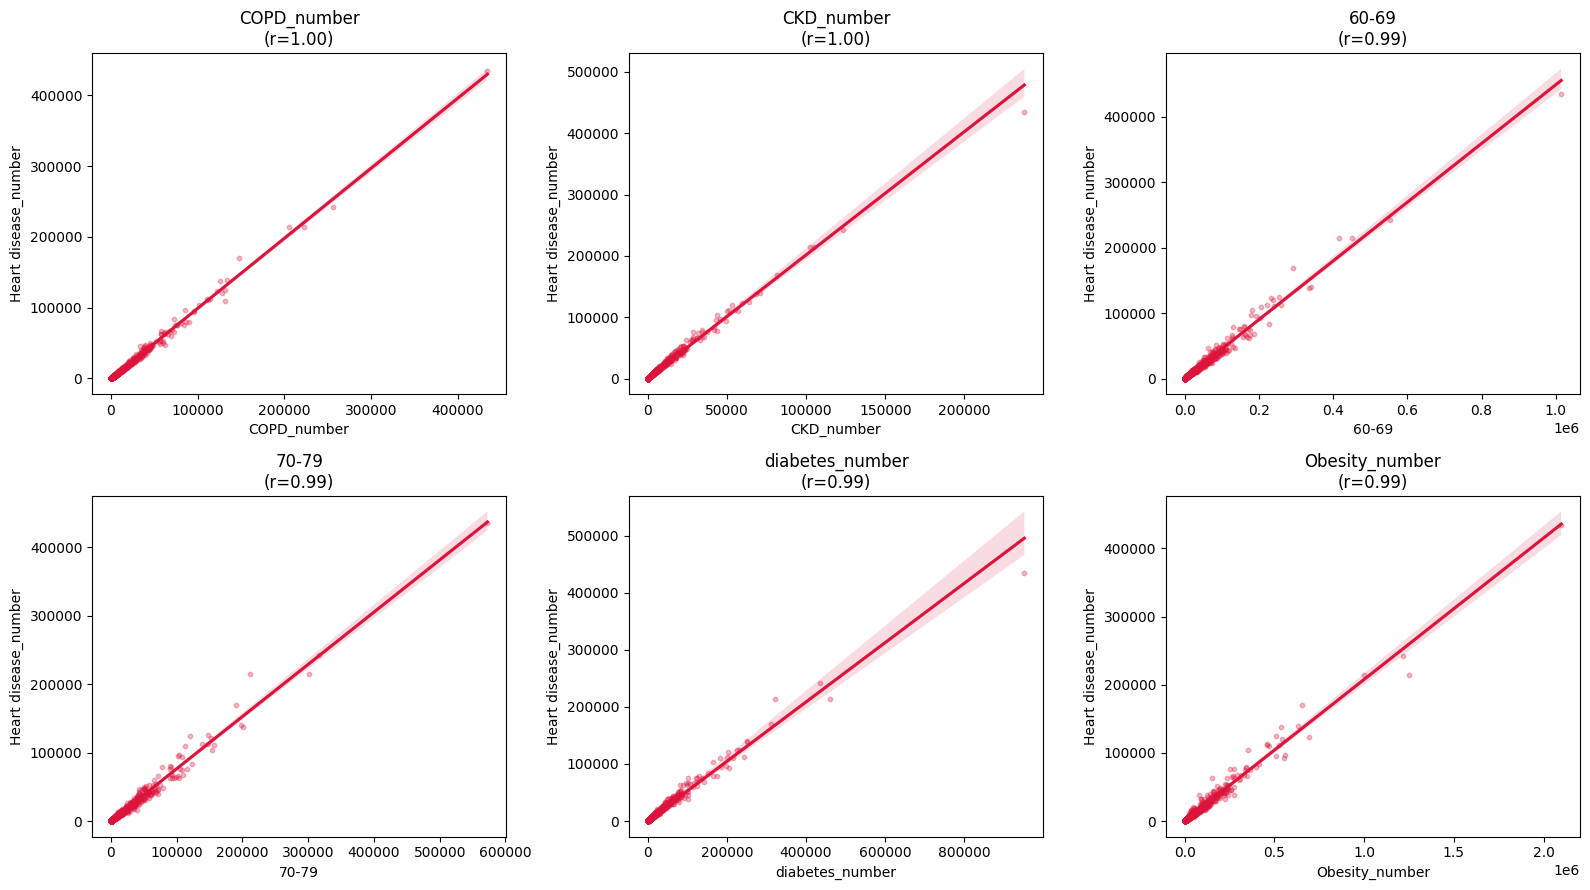

In [29]:
# Scatterplots de las 6 variables con mayor correlación absoluta
top6 = corr_target.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(top6):
    sns.regplot(data=df_sel, x=col, y='Heart disease_number',
                ax=axes[i], scatter_kws={'alpha': 0.3, 's': 10}, color='crimson')
    axes[i].set_title(f'{col[:35]}\n(r={corr_target[col]:.2f})')

plt.tight_layout()
plt.show()

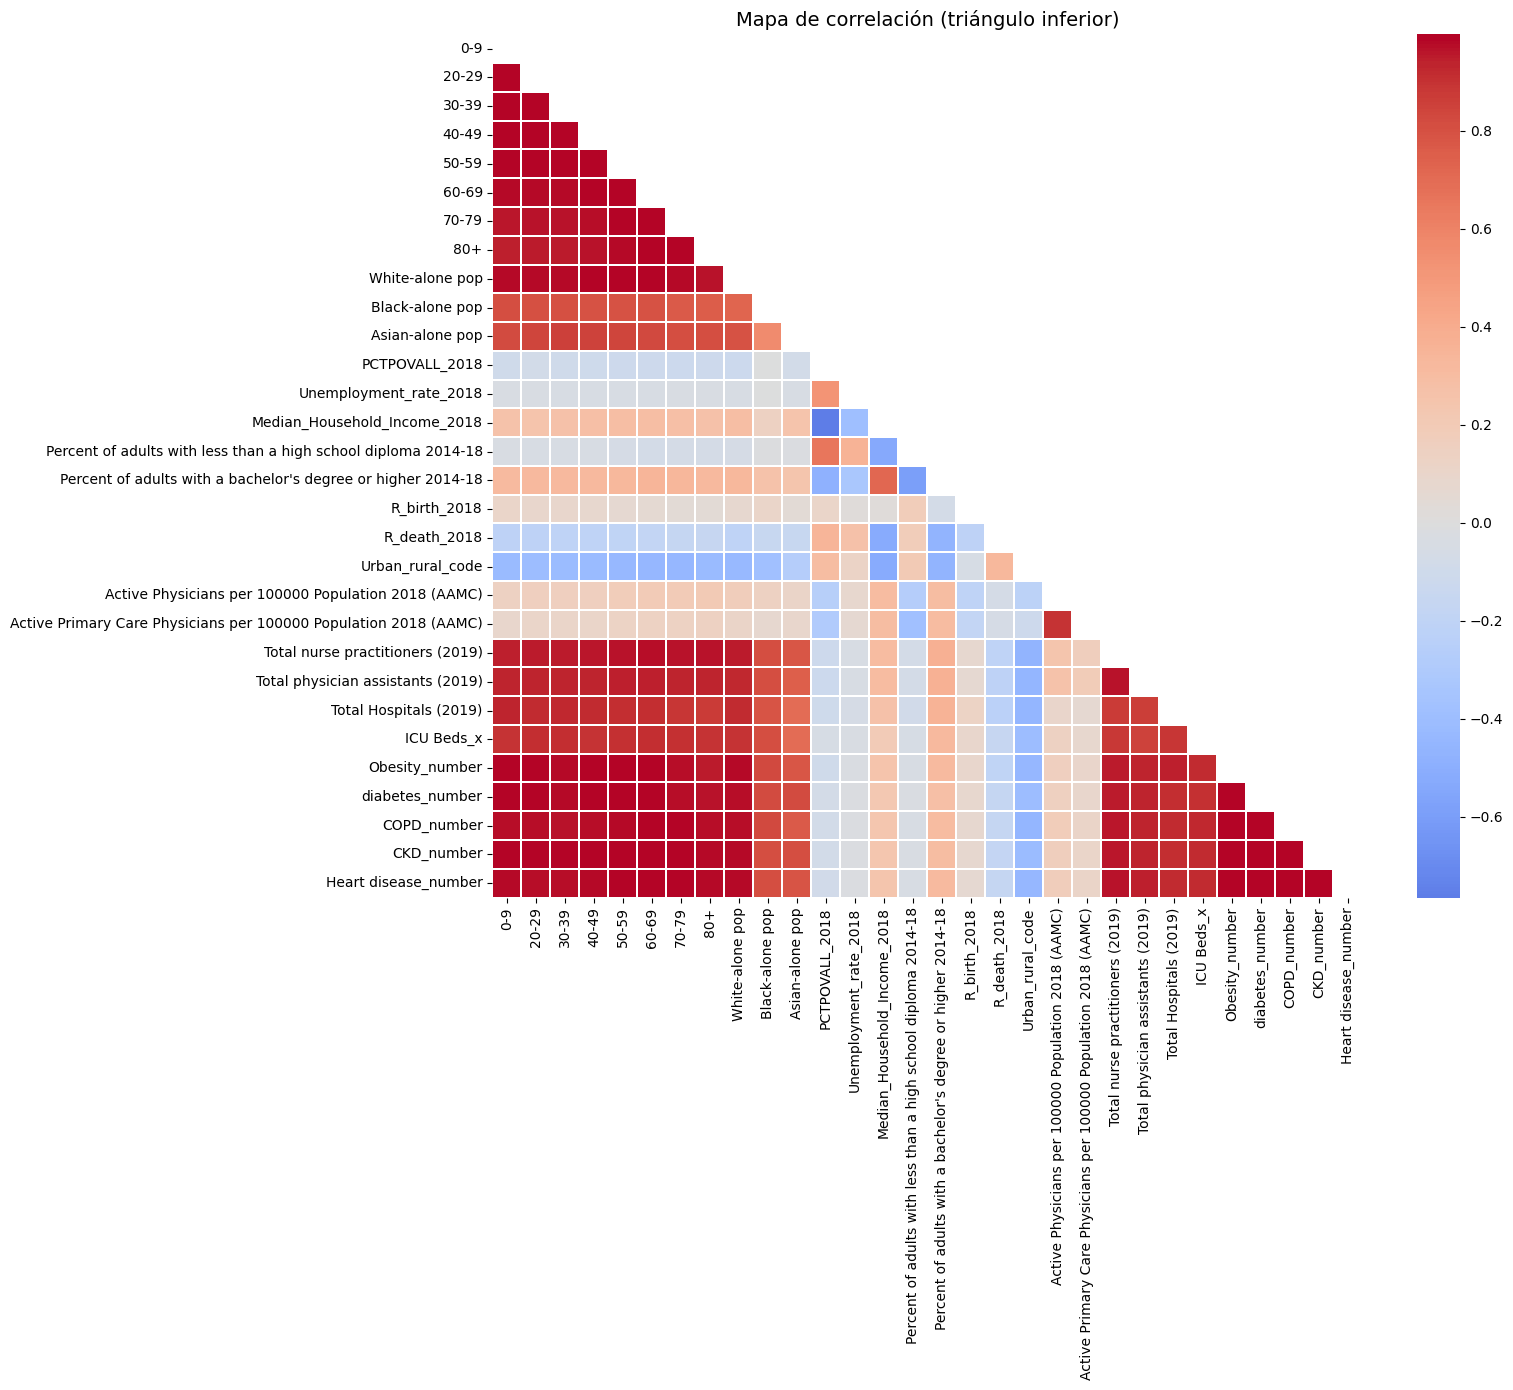

In [30]:
# Mapa correlacion general

fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(df_sel.corr(), dtype=bool))
sns.heatmap(
    df_sel.corr(), mask=mask,
    annot=False, cmap='coolwarm', center=0,
    ax=ax, linewidths=0.3
)
ax.set_title('Mapa de correlación (triángulo inferior)', fontsize=14)
plt.tight_layout()
plt.show()

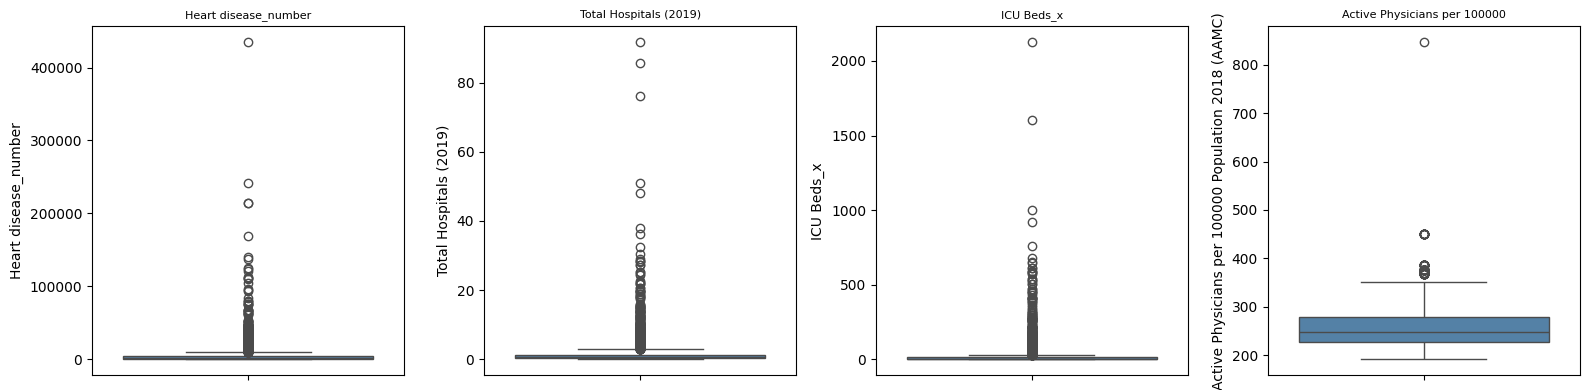

In [31]:
# Outliers
check_cols = ['Heart disease_number', 'Total Hospitals (2019)', 'ICU Beds_x',
              'Active Physicians per 100000 Population 2018 (AAMC)']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, col in enumerate(check_cols):
    sns.boxplot(y=df_sel[col], ax=axes[i], color='steelblue')
    axes[i].set_title(col[:28], fontsize=8)
plt.tight_layout()
plt.show()

In [32]:
# Eliminamos outliers extremos con IQR factor 3 en columnas de recursos
df_clean = df_sel.copy()

outlier_cols = [
    'Total Hospitals (2019)', 'ICU Beds_x',
    'Total nurse practitioners (2019)', 'Total physician assistants (2019)',
    'Active Physicians per 100000 Population 2018 (AAMC)'
]

for col in outlier_cols:
    Q1, Q3 = df_clean[col].quantile(0.25), df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    before = df_clean.shape[0]
    df_clean = df_clean[
        (df_clean[col] >= Q1 - 3*IQR) & (df_clean[col] <= Q3 + 3*IQR)
    ]
    removed = before - df_clean.shape[0]
    if removed > 0:
        print(f'{col[:45]}: {removed} outliers eliminados')

print(f'\nFilas restantes: {df_clean.shape[0]}')

Total Hospitals (2019): 251 outliers eliminados
ICU Beds_x: 207 outliers eliminados
Total nurse practitioners (2019): 88 outliers eliminados
Total physician assistants (2019): 71 outliers eliminados
Active Physicians per 100000 Population 2018 : 3 outliers eliminados

Filas restantes: 2520


In [33]:
# Division train/test
X = df_clean.drop('Heart disease_number', axis=1)
y = df_clean['Heart disease_number']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train_sc.shape[0]} filas | Test: {X_test_sc.shape[0]} filas')
print(f'Variables predictoras: {X_train_sc.shape[1]}')

Train: 2016 filas | Test: 504 filas
Variables predictoras: 29


In [34]:
# Regresión Lineal Base

lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

mse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr  = r2_score(y_test, y_pred_lr)

print('--- Regresión Lineal (base) ---')
print(f'MSE:  {mse_lr:,.2f}')
print(f'RMSE: {np.sqrt(mse_lr):,.2f}')
print(f'R²:   {r2_lr:.4f} ({r2_lr*100:.2f}%)')

--- Regresión Lineal (base) ---
MSE:  5,211.22
RMSE: 72.19
R²:   0.9978 (99.78%)


In [35]:
# Lasso con valores por defecto

lasso_def = Lasso(random_state=42)  # alpha=1.0 por defecto
lasso_def.fit(X_train_sc, y_train)
y_pred_ldef = lasso_def.predict(X_test_sc)

mse_ldef = mean_squared_error(y_test, y_pred_ldef)
r2_ldef  = r2_score(y_test, y_pred_ldef)

print('--- Lasso (alpha=1.0, por defecto) ---')
print(f'MSE:  {mse_ldef:,.2f}')
print(f'RMSE: {np.sqrt(mse_ldef):,.2f}')
print(f'R²:   {r2_ldef:.4f} ({r2_ldef*100:.2f}%)')
print()
n_zero = (lasso_def.coef_ == 0).sum()
print(f'Variables reducidas a 0 por Lasso: {n_zero} de {X.shape[1]}')

--- Lasso (alpha=1.0, por defecto) ---
MSE:  5,628.30
RMSE: 75.02
R²:   0.9976 (99.76%)

Variables reducidas a 0 por Lasso: 9 de 29


In [36]:
# Comparación modelos

comp = pd.DataFrame({
    'Modelo': ['LinearRegression', 'Lasso (alpha=1.0)'],
    'MSE':  [mse_lr, mse_ldef],
    'RMSE': [np.sqrt(mse_lr), np.sqrt(mse_ldef)],
    'R²':   [r2_lr, r2_ldef]
})
print(comp.to_string(index=False))

           Modelo         MSE      RMSE       R²
 LinearRegression 5211.215740 72.188751 0.997794
Lasso (alpha=1.0) 5628.302704 75.022015 0.997617


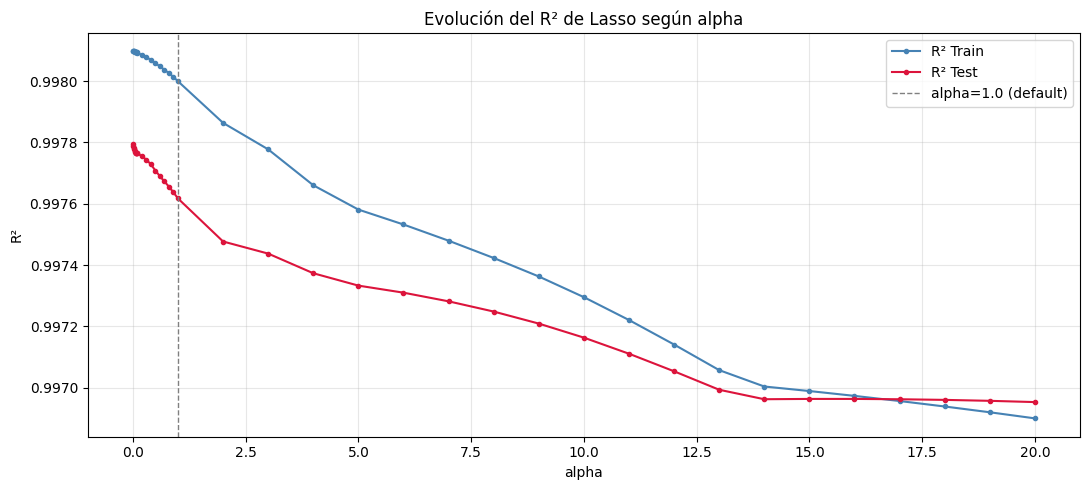

Mejor alpha en test: 0.0 → R² = 0.9978


In [37]:
# Evolución del R²

alphas = list(np.arange(0.0, 0.1, 0.01)) + \
         list(np.arange(0.1, 1.0, 0.1)) + \
         list(np.arange(1, 21, 1))

r2_train_list, r2_test_list = [], []

for a in alphas:
    m = Lasso(alpha=max(a, 1e-6), max_iter=10000, random_state=42)
    m.fit(X_train_sc, y_train)
    r2_train_list.append(r2_score(y_train, m.predict(X_train_sc)))
    r2_test_list.append(r2_score(y_test,  m.predict(X_test_sc)))

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(alphas, r2_train_list, label='R² Train', color='steelblue', marker='o', markersize=3)
ax.plot(alphas, r2_test_list,  label='R² Test',  color='crimson',   marker='o', markersize=3)
ax.axvline(1.0, color='gray', linestyle='--', linewidth=1, label='alpha=1.0 (default)')
ax.set_xlabel('alpha')
ax.set_ylabel('R²')
ax.set_title('Evolución del R² de Lasso según alpha')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_idx   = np.argmax(r2_test_list)
best_alpha = alphas[best_idx]
print(f'Mejor alpha en test: {best_alpha} → R² = {r2_test_list[best_idx]:.4f}')

In [38]:
# Optimización

param_grid = {
    'alpha': list(np.arange(0.001, 0.5, 0.01)) + list(np.arange(0.5, 5.0, 0.1))
}

gs = GridSearchCV(
    Lasso(max_iter=10000, random_state=42),
    param_grid, cv=5, scoring='r2', n_jobs=-1
)
gs.fit(X_train_sc, y_train)

print(f'Mejor alpha (GridSearchCV): {gs.best_params_["alpha"]:.4f}')
print(f'R² en validación cruzada:   {gs.best_score_:.4f}')

Mejor alpha (GridSearchCV): 0.3710
R² en validación cruzada:   0.9978


In [39]:
# Modelo optimizado - métricas finales

best_alpha = gs.best_params_['alpha']

lasso_opt = Lasso(alpha=best_alpha, max_iter=10000, random_state=42)
lasso_opt.fit(X_train_sc, y_train)
y_pred_opt = lasso_opt.predict(X_test_sc)

mse_opt = mean_squared_error(y_test, y_pred_opt)
r2_opt  = r2_score(y_test, y_pred_opt)

print(f'--- Lasso optimizado (alpha={best_alpha:.4f}) ---')
print(f'MSE:  {mse_opt:,.2f}')
print(f'RMSE: {np.sqrt(mse_opt):,.2f}')
print(f'R²:   {r2_opt:.4f} ({r2_opt*100:.2f}%)')
print()
coefs = pd.Series(lasso_opt.coef_, index=X.columns)
print(f'Variables reducidas a 0: {(coefs == 0).sum()} de {len(coefs)}')

--- Lasso optimizado (alpha=0.3710) ---
MSE:  5,353.83
RMSE: 73.17
R²:   0.9977 (99.77%)

Variables reducidas a 0: 5 de 29


In [42]:
import pickle

# Guardar modelo
with open('..\models\lasso_model.pkl', 'wb') as f:
    pickle.dump(lasso_opt, f)

# Guardar scaler 
with open('..\models\scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Modelo y scaler guardados correctamente")

Modelo y scaler guardados correctamente
